In [63]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/thasankakandage/ufc-dataset-2024/ufc_fighters_avg.csv
/kaggle/input/datasets/thasankakandage/ufc-dataset-2024/ufc_event_fight_stats.csv
/kaggle/input/datasets/thasankakandage/ufc-dataset-2024/ufc_fighters_median.csv
/kaggle/input/datasets/thasankakandage/ufc-dataset-2024/ufc_fighters.csv
/kaggle/input/datasets/thasankakandage/ufc-dataset-2024/ufc_events.csv


In [64]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/thasankakandage/ufc-dataset-2024/ufc_fighters_avg.csv')

print(df.columns.tolist())
print(df.head())

['fighter_id', 'fighter_name', 'fighter_dob', 'fighter_height_cm', 'fighter_weight_lbs', 'fighter_reach_cm', 'fighter_stance', 'fighter_wins', 'fighter_losses', 'fighter_draws', 'fighter_slpm', 'fighter_str_acc_%', 'fighter_sapm', 'fighter_str_def_%', 'fighter_td_avg', 'fighter_td_acc_%', 'fighter_td_def_%', 'fighter_sub_avg', 'fighter_url', 'avg_knockdowns', 'avg_sig_strike_atts', 'avg_sig_strikes', 'avg_tot_strike_atts', 'avg_tot_strikes', 'avg_takedown_atts', 'avg_takedowns', 'avg_clinch_atts', 'avg_clinchs', 'avg_ctrl_time', 'avg_total_fight_time', 'avg_submissions', 'avg_reversals', 'avg_head_strike_atts', 'avg_head_strikes', 'avg_body_strike_atts', 'avg_body_strikes', 'avg_leg_strike_atts', 'avg_leg_strikes', 'avg_dist_strike_atts', 'avg_dist_strikes', 'avg_ground_atts', 'avg_grounds']
   fighter_id      fighter_name fighter_dob  fighter_height_cm  \
0           1         Tom Aaron  1978-07-13                NaN   
1           2      Danny Abbadi  1983-07-03             180.34   

In [65]:
# Try to identify the fighter name column
possible_name_cols = ['name', 'fighter_name', 'fighter', 'Name', 'Fighter']
name_col = None

for col in possible_name_cols:
    if col in df.columns:
        name_col = col
        break

print("Name column found:", name_col)

Name column found: fighter_name


In [66]:
fighters = ['Joshua Van', 'Alex Pereira', "Sean O'Malley", 'Sean O Malley']

filtered = df[
    df[name_col].astype(str).str.contains('|'.join(fighters), case=False, na=False, regex=True)
].copy()

print(filtered)

      fighter_id   fighter_name fighter_dob  fighter_height_cm  \
2774        2775  Sean O'Malley  1994-10-24             180.34   
2952        2953   Alex Pereira  1987-07-07             193.04   
3954        3955     Joshua Van  2001-10-10             165.10   

      fighter_weight_lbs  fighter_reach_cm fighter_stance  fighter_wins  \
2774               135.0            182.88         Switch            18   
2952               205.0            200.66       Orthodox            12   
3954               125.0            165.10       Orthodox            11   

      fighter_losses  fighter_draws  ...  avg_head_strike_atts  \
2774               2              0  ...             95.923077   
2952               2              0  ...             56.000000   
3954               2              0  ...            156.600000   

      avg_head_strikes  avg_body_strike_atts  avg_body_strikes  \
2774         53.076923             23.384615         17.769231   
2952         29.100000             19

In [67]:
print(df.select_dtypes(include='number').columns.tolist())

['fighter_id', 'fighter_height_cm', 'fighter_weight_lbs', 'fighter_reach_cm', 'fighter_wins', 'fighter_losses', 'fighter_draws', 'fighter_slpm', 'fighter_str_acc_%', 'fighter_sapm', 'fighter_str_def_%', 'fighter_td_avg', 'fighter_td_acc_%', 'fighter_td_def_%', 'fighter_sub_avg', 'avg_knockdowns', 'avg_sig_strike_atts', 'avg_sig_strikes', 'avg_tot_strike_atts', 'avg_tot_strikes', 'avg_takedown_atts', 'avg_takedowns', 'avg_clinch_atts', 'avg_clinchs', 'avg_ctrl_time', 'avg_total_fight_time', 'avg_submissions', 'avg_reversals', 'avg_head_strike_atts', 'avg_head_strikes', 'avg_body_strike_atts', 'avg_body_strikes', 'avg_leg_strike_atts', 'avg_leg_strikes', 'avg_dist_strike_atts', 'avg_dist_strikes', 'avg_ground_atts', 'avg_grounds']


In [68]:
import pandas as pd
import matplotlib.pyplot as plt

# Load file
df = pd.read_csv('/kaggle/input/datasets/thasankakandage/ufc-dataset-2024/ufc_fighters_avg.csv')

# Fighter name column
name_col = 'fighter_name'

# Fighters you want
fighters = ['Joshua Van', 'Alex Pereira', "Sean O'Malley", 'Sean O Malley']

# Filter matching fighters
filtered = df[df[name_col].astype(str).str.contains('|'.join(fighters), case=False, na=False)].copy()

# Keep only the first match for each fighter name just in case
filtered = filtered.drop_duplicates(subset=[name_col])

print(filtered[[name_col, 'fighter_wins', 'fighter_losses', 'fighter_slpm', 'fighter_td_avg']])

       fighter_name  fighter_wins  fighter_losses  fighter_slpm  \
2774  Sean O'Malley            18               2          6.70   
2952   Alex Pereira            12               2          5.46   
3954     Joshua Van            11               2          8.39   

      fighter_td_avg  
2774            0.29  
2952            0.14  
3954            1.62  


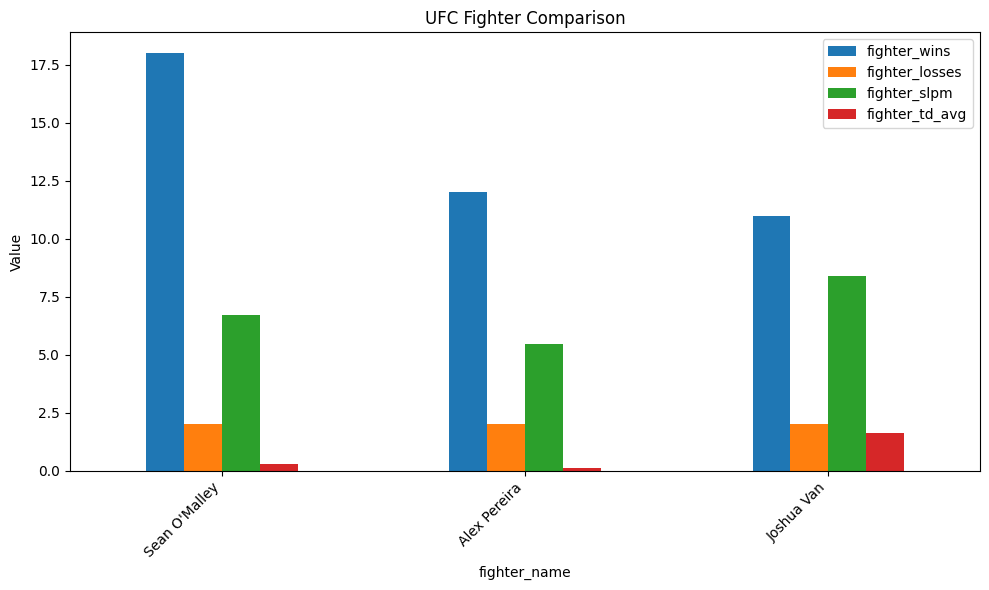

In [69]:
plot_df = filtered[[name_col, 'fighter_wins', 'fighter_losses', 'fighter_slpm', 'fighter_td_avg']].copy()
plot_df = plot_df.set_index(name_col)

plot_df.plot(kind='bar', figsize=(10, 6))
plt.title('UFC Fighter Comparison')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

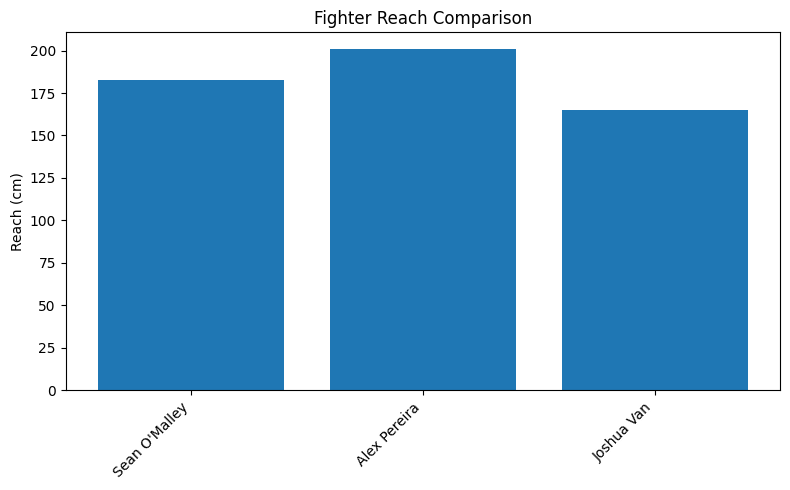

In [70]:
plt.figure(figsize=(8, 5))
plt.bar(filtered[name_col], filtered['fighter_reach_cm'])
plt.title('Fighter Reach Comparison')
plt.ylabel('Reach (cm)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

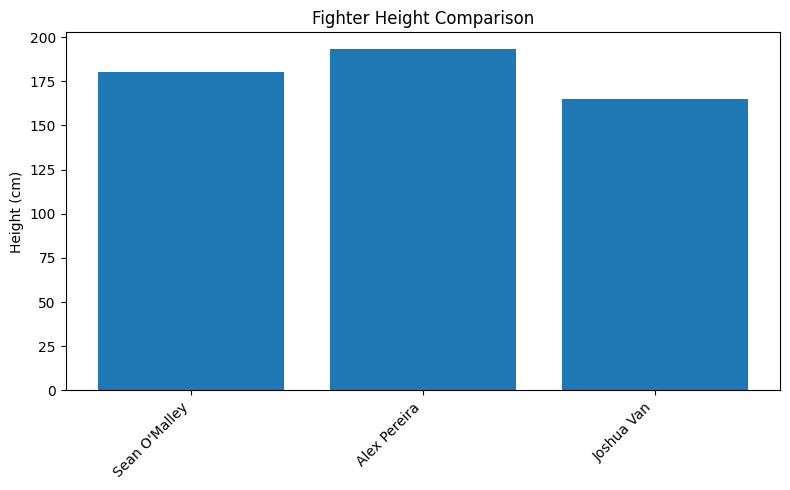

In [71]:
plt.figure(figsize=(8, 5))
plt.bar(filtered[name_col], filtered['fighter_height_cm'])
plt.title('Fighter Height Comparison')
plt.ylabel('Height (cm)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()